<a href="https://colab.research.google.com/github/SebMun33/AA1-TUIA-Munoz-Onyskiw-Calenta/blob/main/TP_AA1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Importamos las librerias

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


##Cargamos el dataframe🛢

In [2]:
df = pd.read_csv('weatherAUS_2026C1.csv')

##Ver si las columnas tienen nombres coherentes y si los datos parecen estar en su lugar NOTA: el head es un método para dar un vistazo rápido al dataset, pero no es un método correcto para revisar las columnas de este dataset ya que te omite columnas al haber mucha, inmediatamente desp del head sería bueno usar un .columns, cómo el de más abajo

In [3]:
df.head()

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2


Aqui veremos cuántas entradas hay y si las columnas son float64, int64 o object

In [4]:
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")
df.info()

El dataset tiene 145412 filas y 25 columnas.
<class 'pandas.DataFrame'>
RangeIndex: 145412 entries, 0 to 145411
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        145412 non-null  int64  
 1   Date              145412 non-null  str    
 2   Location          145412 non-null  str    
 3   MinTemp           143928 non-null  float64
 4   MaxTemp           144159 non-null  float64
 5   Rainfall          142152 non-null  float64
 6   Evaporation       82658 non-null   float64
 7   Sunshine          75616 non-null   float64
 8   WindGustDir       135096 non-null  str    
 9   WindGustSpeed     135159 non-null  float64
 10  WindDir9am        134850 non-null  str    
 11  WindDir3pm        141186 non-null  str    
 12  WindSpeed9am      143645 non-null  float64
 13  WindSpeed3pm      142351 non-null  float64
 14  Humidity9am       142759 non-null  float64
 15  Humidity3pm       140907 non-null 

##Eliminamos la columna Unnamed: 0 ya q notamos q es un indice redundante q no aporta informacion climatica

In [5]:
# Eliminamos la columna indicando axis=1 e inplace=True para aplicar el cambio al df original
df.drop('Unnamed: 0', axis=1, inplace=True)

df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow', 'RainfallTomorrow'],
      dtype='str')

##Aqui transformamos la columna Date  de tipo Object a datetime, ya q es importante identificar correctamente los tipos de variables, con el objetivo de habilitar la capacidad de analizar los datos

In [6]:
# Convertimos a formato fecha
df['Date'] = pd.to_datetime(df['Date'])

print(f"Nuevo tipo de dato de Date: {df['Date'].dtype}")

Nuevo tipo de dato de Date: datetime64[us]


##Convertimos las columnas de texto a minusculas y eliminamos espacios en blanco para poder evitar duplicacion de categoria por errores de tipeo

In [7]:
#seleccionamos columnas tipo objeto
cols_texto = df.select_dtypes(include=['object']).columns

for col in cols_texto:
    df[col] = df[col].str.lower().str.strip()

df['Location'].unique()
#verificamos algunas categorias


E:\temp\ipykernel_30548\2910713353.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_texto = df.select_dtypes(include=['object']).columns


<StringArray>
[          'albury',    'badgeryscreek',            'cobar',
     'coffsharbour',            'moree',        'newcastle',
        'norahhead',    'norfolkisland',          'penrith',
         'richmond',           'sydney',    'sydneyairport',
       'waggawagga',      'williamtown',       'wollongong',
         'canberra',      'tuggeranong',      'mountginini',
         'ballarat',          'bendigo',             'sale',
 'melbourneairport',        'melbourne',          'mildura',
             'nhil',         'portland',         'watsonia',
         'dartmoor',         'brisbane',           'cairns',
        'goldcoast',       'townsville',         'adelaide',
     'mountgambier',        'nuriootpa',          'woomera',
           'albany',      'witchcliffe',       'pearceraaf',
     'perthairport',            'perth',       'salmongums',
          'walpole',           'hobart',       'launceston',
     'alicesprings',           'darwin',        'katherine',
          

##Ahora calcularemos el porcentaje de datos nulos por cada columna, ya q si hay muchos podria ser no coanfiable. Al identificarlas no ayudara a elegir entre eliminar filas o completar los datos

In [8]:
# Sumamos los nulos y calculamos su porcentaje sobre el total de filas
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df)) * 100

# creamos una tabla para verlo mejor
tabla_nulos = pd.DataFrame({'Nulos Totales': nulos, 'Porcentaje (%)': nulos_pct})
print(tabla_nulos.sort_values(by='Porcentaje (%)', ascending=False))

                  Nulos Totales  Porcentaje (%)
Sunshine                  69796       47.998790
Evaporation               62754       43.155998
Cloud3pm                  59336       40.805436
Cloud9am                  55870       38.421863
Pressure9am               15061       10.357467
Pressure3pm               15024       10.332022
WindDir9am                10562        7.263500
WindGustDir               10316        7.094325
WindGustSpeed             10253        7.051000
Humidity3pm                4505        3.098094
WindDir3pm                 4226        2.906225
Temp3pm                    3607        2.480538
Rainfall                   3260        2.241906
RainToday                  3260        2.241906
RainfallTomorrow           3259        2.241218
RainTomorrow               3259        2.241218
WindSpeed3pm               3061        2.105053
Humidity9am                2653        1.824471
WindSpeed9am               1767        1.215168
Temp9am                    1766        1

##Aqui eliminaremos las filas donde la columna RainTomorrow sean nulas. Esto para a futuro poder predecir si llovera mañana, los registros q no tienen ese dato no serven para entrenar un modelo

In [9]:
#eliminamos registros con datos nulos solo en la columna objetivo
df.dropna(subset=['RainTomorrow'], inplace=True)

print(f"registro finales despues de la limpieza: {df.shape[0]}")

registro finales despues de la limpieza: 142153


##Se crea una nueva columna llamada month a partir de la columna Date par poder revelar pratones ocultos en el clima, el mes es una variable mucho mas explicativa q la fecha exacta NOTA: por qué es más explicativa el més que el día?

In [10]:
#al ya haber convertido Date a datetime antes podemos extraer el mes facilmente
df['Month'] = df['Date'].dt.month

#comprobamos la creacion de la nueva variable
df[['Date', 'Month']].head()


,Date,Month
0,2008-12-01,12
1,2008-12-02,12
2,2008-12-03,12
3,2008-12-04,12
4,2008-12-05,12


##📊 En esta celda generamos un grafico de barras para ver las columnas mas complicadas, esto para poder ver si las variables  Rainfal o Maxtemp estan muy afectadas

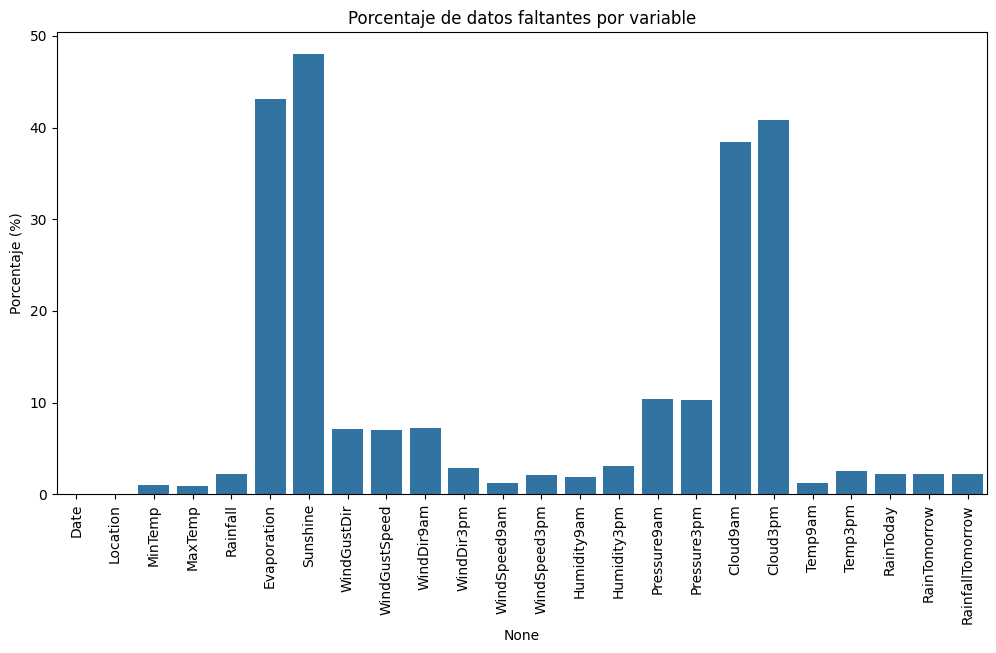

In [11]:
plt.figure(figsize=(12, 6))
sns.barplot(x=tabla_nulos.index, y=tabla_nulos['Porcentaje (%)'])
plt.xticks(rotation=90)
plt.title('Porcentaje de datos faltantes por variable')
plt.show()

## 📊 lo q vemos es q las variables Evaporation Y Sushine tienen una falta de datos mayor de 35%. Debido a este porcentaje tan alto la imputacion simple puede ser arriesgada, para esta EDA inicial mantendre las columnas pero tendre precaucion al sacar conclusiones de estas. Mientras q para variables menor al 5% optaremos por la imputacion simple NOTA:cuidado con el sujeto de las oraciones, para informes de este estilo hablamos siempre en primera persona en plural, porque estamos hablando cómo un grupo, no cómo individuo

##Ahora crearemos un diagrama de caja (boxplot) para la variable MaxTemp, ya q nos permite indentificar visualmente la mediana, los cuartiles y ---los valores q se alejan del resto (puntos fuera de lo bigotes)--- *los outliers* .Y luego determinar si existen registros climaticos extremos q puedan ser errores de sensor o evento climaticos muy inusuales

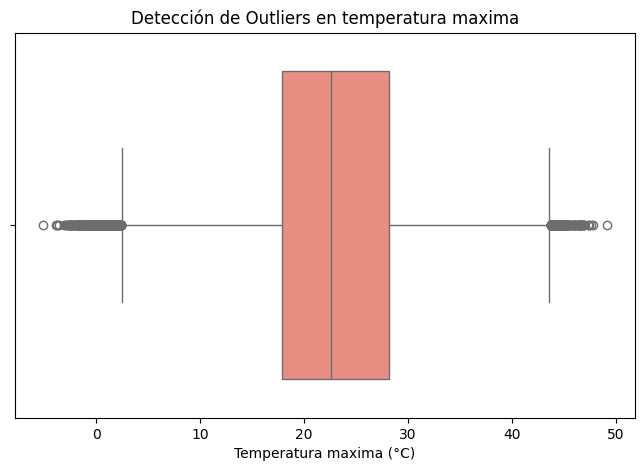

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['MaxTemp'], color='salmon')
plt.title('Detección de Outliers en temperatura maxima')
plt.xlabel('Temperatura maxima (°C)')
plt.show()

##🌡️Lo q podemos ver es q la linea central dentro de la caja es la mediana. Los puntos q aparecen a la derecha 'si es q lo hay' son los outliers. Con esto podemos concluir q si vemos temp de 50 grados podrian ser reales en las partes de Australia mas deserticas pero de ser el caso de ver 100 grados seria un error de carga. Dada la situacion mantendremos esos datos

NOTA: hay que ser más tecnicos con el lenguaje, no hace falta explicar los elementos de un diagrama salvo que se esté usando un gráfico póco usual o no dado en la carrera

##Luego de esto vamos a realizar el analisis brivariante usando la matriz de correlacion ya q sirve para ver la relacion entre variable entre si. Para esto calcularemos e imprimimos un mapa de calor de la correlaciones entre las variables numericas, haremos esto pq las variables altamente correlacionadas dan informacion similar, al identificarlas ayudara a entender la estructura del dataset para evitar redundancias. Esto lo haremos con el objetivo de si hay factores climaticos q se muevan juntos

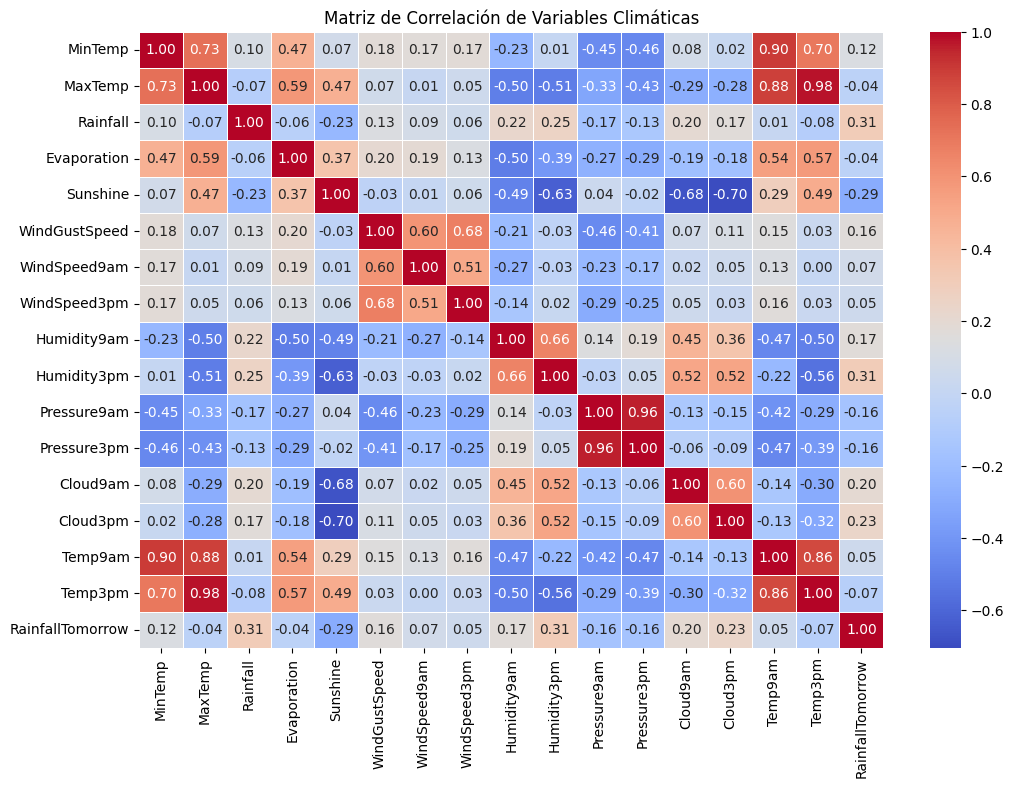

In [13]:
#seleccionamos solo las columnas con numeros para poder calcular la correlacion
corr = df.select_dtypes(include=['float64', 'int64']).corr()

#configuramos el tamaño del grafico
plt.figure(figsize=(12, 8))

# Creamos el mapa de calor
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Matriz de Correlación de Variables Climáticas')
plt.show()

NOTA: no hay conclusión del eda, o un insight sobre el grafico de correlación, en lo personal encuentro los emojis cómo algo poco serio, cuidado con los typos y cómo explicas las cosas, tené en cuenta que comentar cada línea de código tampoco es necesario o queda bien, hay que usar la cantidad justa de comentarios, generalmente para explicar que hace algo que a simple vista puede no quedar claro